# Stage 02: Exploratory Data Analysis

Analyze the collected F1 data to uncover patterns, distributions, and correlations that will inform feature engineering and modeling.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from src.data_pipeline import load_race_results, load_qualifying_results, load_circuits

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color palette for teams
TEAM_COLORS = {
    'Mercedes': '#00D2BE', 'Red Bull': '#1E41FF', 'Ferrari': '#DC143C',
    'McLaren': '#FF8700', 'Alpine F1 Team': '#0090FF', 'Aston Martin': '#006F62',
    'AlphaTauri': '#2B4562', 'Alfa Romeo': '#900000', 'Haas F1 Team': '#FFFFFF',
    'Williams': '#005AFF', 'RB F1 Team': '#6692FF', 'Racing Point': '#F596C8',
    'Renault': '#FFF500', 'Force India': '#F596C8', 'Toro Rosso': '#469BFF',
    'Sauber': '#9B0000', 'Lotus F1': '#FFB800', 'Manor Marussia': '#6E0000',
    'Marussia': '#6E0000', 'Caterham': '#005030',
}

SAVE_DIR = '../outputs/figures/'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

## 2.1 Load Data

In [2]:
race_df = load_race_results()
qual_df = load_qualifying_results()
circuits_df = load_circuits()

print(f"Race Results:  {race_df.shape[0]:,} rows x {race_df.shape[1]} cols")
print(f"Qualifying:    {qual_df.shape[0]:,} rows x {qual_df.shape[1]} cols")
print(f"Circuits:      {circuits_df.shape[0]:,} rows x {circuits_df.shape[1]} cols")
print(f"\nSeasons: {race_df['season'].min()} - {race_df['season'].max()}")
print(f"Unique drivers: {race_df['driverId'].nunique()}")
print(f"Unique constructors: {race_df['constructorName'].nunique()}")
print(f"Unique circuits: {race_df['circuitId'].nunique()}")

# Flag DNFs: anything not "Finished" or lapped ("+N Lap(s)")
race_df['is_dnf'] = ~race_df['status'].str.contains(r'Finished|Lap', regex=True)
race_df['position_gain'] = race_df['grid'] - race_df['position']  # positive = gained positions

print(f"\nDNF rate: {race_df['is_dnf'].mean():.1%}")
print(f"\nMissing values in race_df:")
print(race_df.isnull().sum()[race_df.isnull().sum() > 0] if race_df.isnull().any().any() else "  None")
print(f"\nMissing values in qual_df:")
print(qual_df.isnull().sum()[qual_df.isnull().sum() > 0])

Race Results:  4,626 rows x 15 cols
Qualifying:    4,610 rows x 10 cols
Circuits:      78 rows x 5 cols

Seasons: 2014 - 2024
Unique drivers: 59
Unique constructors: 20
Unique circuits: 32

DNF rate: 17.3%

Missing values in race_df:
  None

Missing values in qual_df:
Q1      51
Q2    1221
Q3    2396
dtype: int64


## 2.2 Race Results Distribution

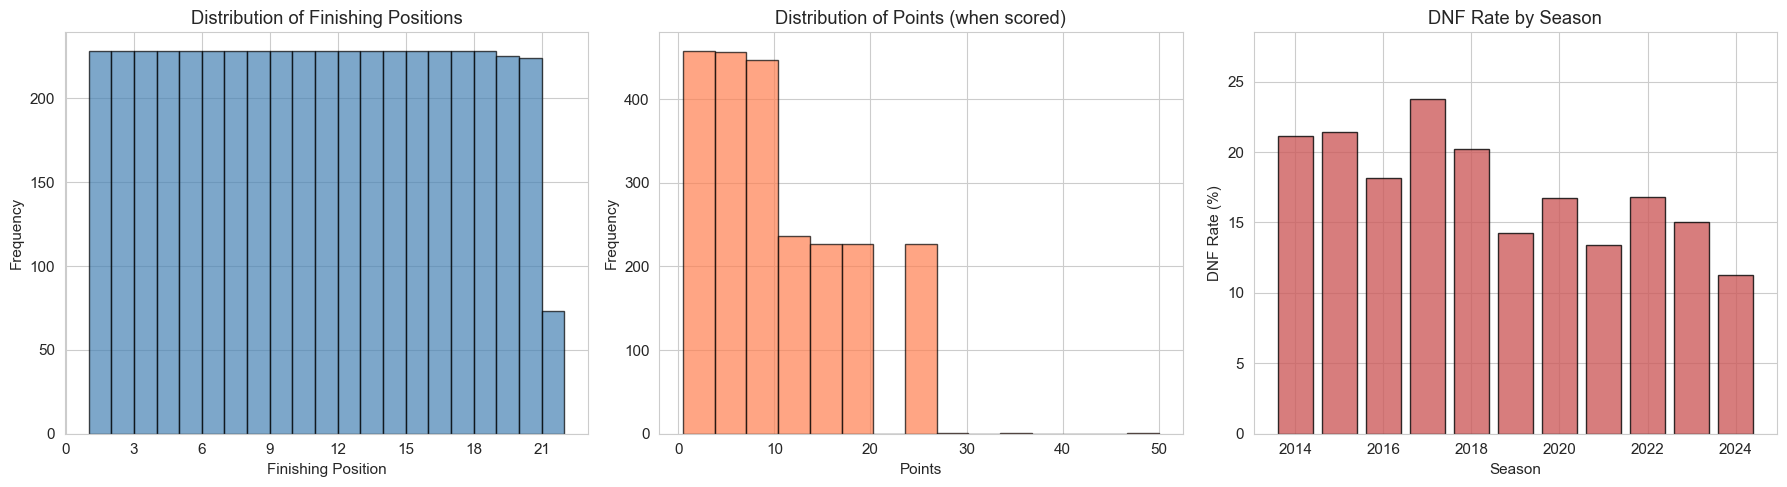

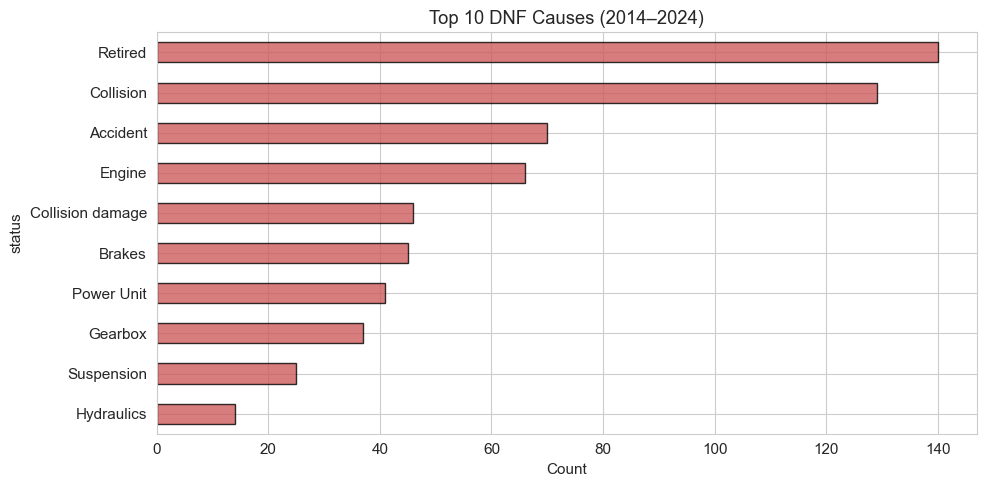

Total DNFs: 801 (17.3% of all race entries)
Most common cause: Retired (140 occurrences)


In [3]:
# --- Finishing position distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of finishing positions
axes[0].hist(race_df['position'], bins=range(1, 23), edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Finishing Position')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Finishing Positions')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Points distribution (non-zero)
points_scored = race_df[race_df['points'] > 0]['points']
axes[1].hist(points_scored, bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Points')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Points (when scored)')

# DNF rate by season
dnf_by_season = race_df.groupby('season')['is_dnf'].mean() * 100
axes[2].bar(dnf_by_season.index, dnf_by_season.values, color='indianred', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('Season')
axes[2].set_ylabel('DNF Rate (%)')
axes[2].set_title('DNF Rate by Season')
axes[2].set_ylim(0, dnf_by_season.max() * 1.2)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}race_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# --- DNF causes breakdown ---
dnf_data = race_df[race_df['is_dnf']]
dnf_causes = dnf_data['status'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
dnf_causes.plot(kind='barh', ax=ax, color='indianred', edgecolor='black', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('Top 10 DNF Causes (2014–2024)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}dnf_causes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total DNFs: {len(dnf_data):,} ({race_df['is_dnf'].mean():.1%} of all race entries)")
print(f"Most common cause: {dnf_causes.index[0]} ({dnf_causes.iloc[0]} occurrences)")

## 2.3 Driver Performance Trends

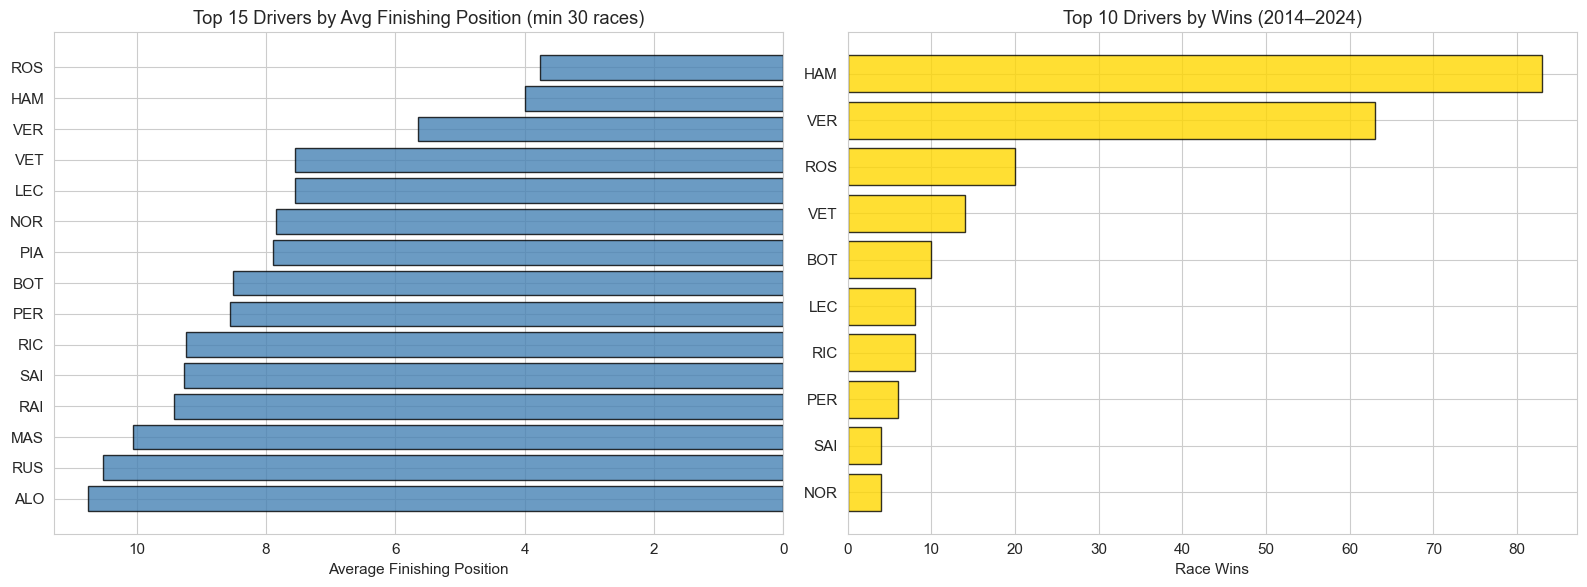

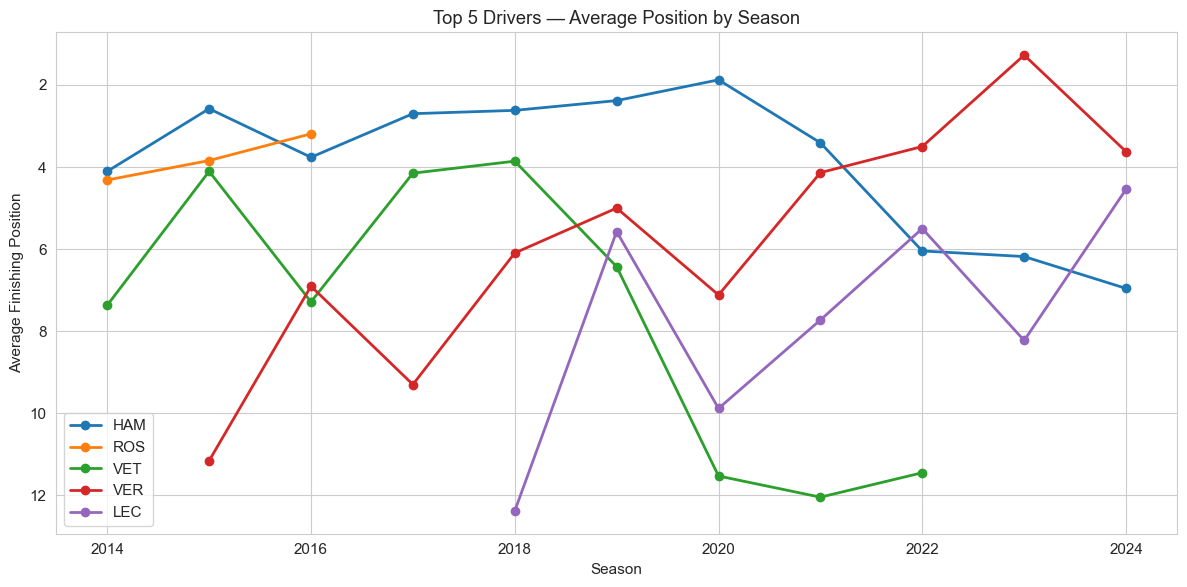

driverCode  avg_position  avg_points  races  wins  podiums  dnf_rate
       ROS      3.762712   17.355932     59    20       46  0.067797
       HAM      3.991189   16.381057    227    83      148  0.061674
       VER      5.645933   13.935407    209    63      112  0.153110
       VET      7.555556    9.150000    180    14       60  0.138889
       LEC      7.557047    9.147651    149     8       43  0.161074
       NOR      7.851562    7.421875    128     4       26  0.085938
       PIA      7.891304    7.543478     46     2       10  0.065217
       BOT      8.513158    7.824561    228    10       67  0.122807
       PER      8.561947    6.442478    226     6       36  0.123894
       RIC      9.231884    6.231884    207     8       32  0.159420
       SAI      9.274038    5.786058    208     4       27  0.192308
       RAI      9.417722    5.721519    158     1       26  0.145570
       MAS     10.064103    4.500000     78     0        5  0.166667
       RUS     10.531250    5.1875

In [4]:
# --- Top drivers by average finishing position (min 30 races) ---
driver_stats = race_df.groupby(['driverId', 'driverCode']).agg(
    avg_position=('position', 'mean'),
    avg_points=('points', 'mean'),
    races=('position', 'count'),
    wins=('position', lambda x: (x == 1).sum()),
    podiums=('position', lambda x: (x <= 3).sum()),
    dnf_rate=('is_dnf', 'mean'),
).reset_index()

top_drivers = driver_stats[driver_stats['races'] >= 30].sort_values('avg_position').head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average finishing position
axes[0].barh(top_drivers['driverCode'], top_drivers['avg_position'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Average Finishing Position')
axes[0].set_title('Top 15 Drivers by Avg Finishing Position (min 30 races)')
axes[0].invert_yaxis()
axes[0].invert_xaxis()

# Win count
top_winners = driver_stats.sort_values('wins', ascending=False).head(10)
axes[1].barh(top_winners['driverCode'], top_winners['wins'], color='gold', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Race Wins')
axes[1].set_title('Top 10 Drivers by Wins (2014–2024)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}driver_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Driver performance trend over seasons ---
top_5_ids = top_drivers.head(5)['driverId'].tolist()
season_perf = race_df[race_df['driverId'].isin(top_5_ids)].groupby(
    ['season', 'driverCode']
)['position'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for driver in season_perf['driverCode'].unique():
    d = season_perf[season_perf['driverCode'] == driver]
    ax.plot(d['season'], d['position'], marker='o', linewidth=2, label=driver)

ax.set_xlabel('Season')
ax.set_ylabel('Average Finishing Position')
ax.set_title('Top 5 Drivers — Average Position by Season')
ax.invert_yaxis()
ax.legend(loc='best')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}driver_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_drivers[['driverCode', 'avg_position', 'avg_points', 'races', 'wins', 'podiums', 'dnf_rate']].to_string(index=False))

## 2.4 Team/Constructor Analysis

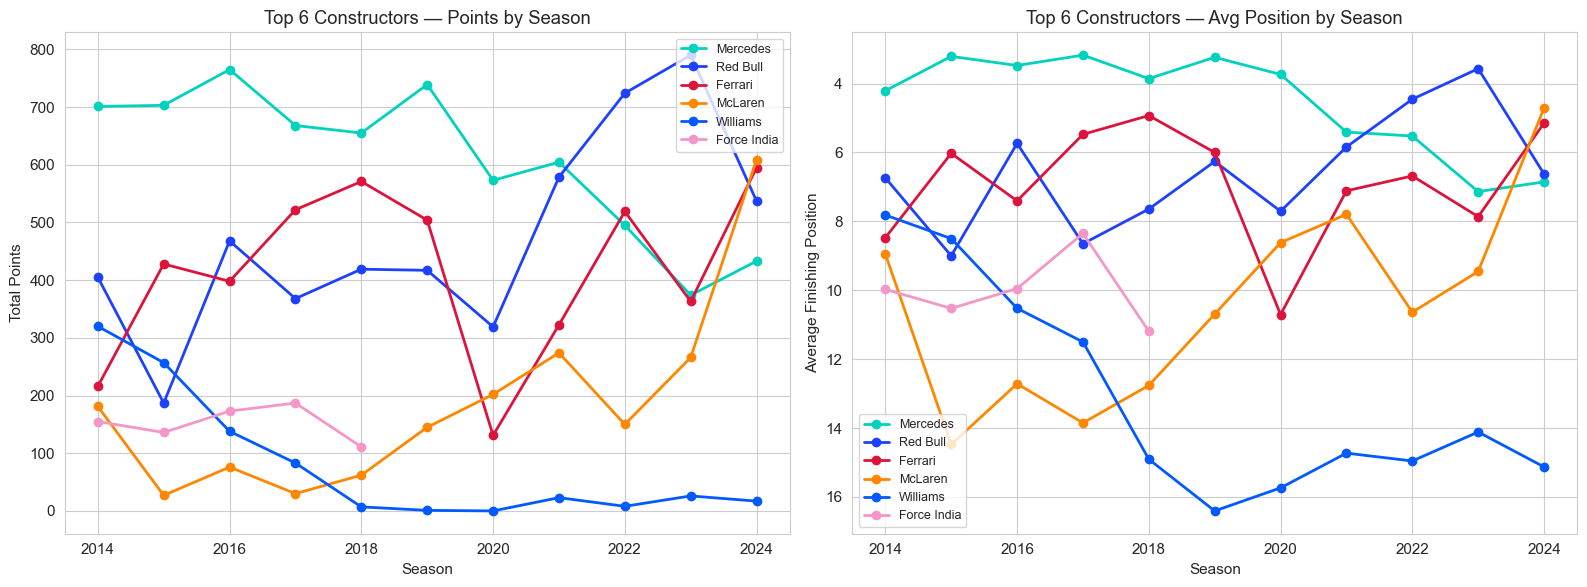

Constructor with most wins per season:
 season constructorName  wins
   2014        Mercedes    16
   2015        Mercedes    16
   2016        Mercedes    19
   2017        Mercedes    12
   2018        Mercedes    11
   2019        Mercedes    15
   2020        Mercedes    13
   2021        Red Bull    11
   2022        Red Bull    17
   2023        Red Bull    21
   2024        Red Bull     9


In [5]:
# --- Constructor championship points by season ---
team_season = race_df.groupby(['season', 'constructorName']).agg(
    total_points=('points', 'sum'),
    avg_position=('position', 'mean'),
    races=('position', 'count'),
).reset_index()

# Top constructors across the era
top_constructors = team_season.groupby('constructorName')['total_points'].sum().nlargest(6).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Points trajectory
for team in top_constructors:
    d = team_season[team_season['constructorName'] == team]
    color = TEAM_COLORS.get(team, '#888888')
    axes[0].plot(d['season'], d['total_points'], marker='o', linewidth=2, label=team, color=color)

axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Points')
axes[0].set_title('Top 6 Constructors — Points by Season')
axes[0].legend(loc='best', fontsize=9)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Average position trajectory
for team in top_constructors:
    d = team_season[team_season['constructorName'] == team]
    color = TEAM_COLORS.get(team, '#888888')
    axes[1].plot(d['season'], d['avg_position'], marker='o', linewidth=2, label=team, color=color)

axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Finishing Position')
axes[1].set_title('Top 6 Constructors — Avg Position by Season')
axes[1].invert_yaxis()
axes[1].legend(loc='best', fontsize=9)
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}constructor_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Dominance: which team won the most races per season ---
winners = race_df[race_df['position'] == 1].groupby(['season', 'constructorName']).size().reset_index(name='wins')
season_winners = winners.loc[winners.groupby('season')['wins'].idxmax()]
print("Constructor with most wins per season:")
print(season_winners[['season', 'constructorName', 'wins']].to_string(index=False))

## 2.5 Qualifying vs Race Correlation

Merged dataset: 4,610 rows (inner join)


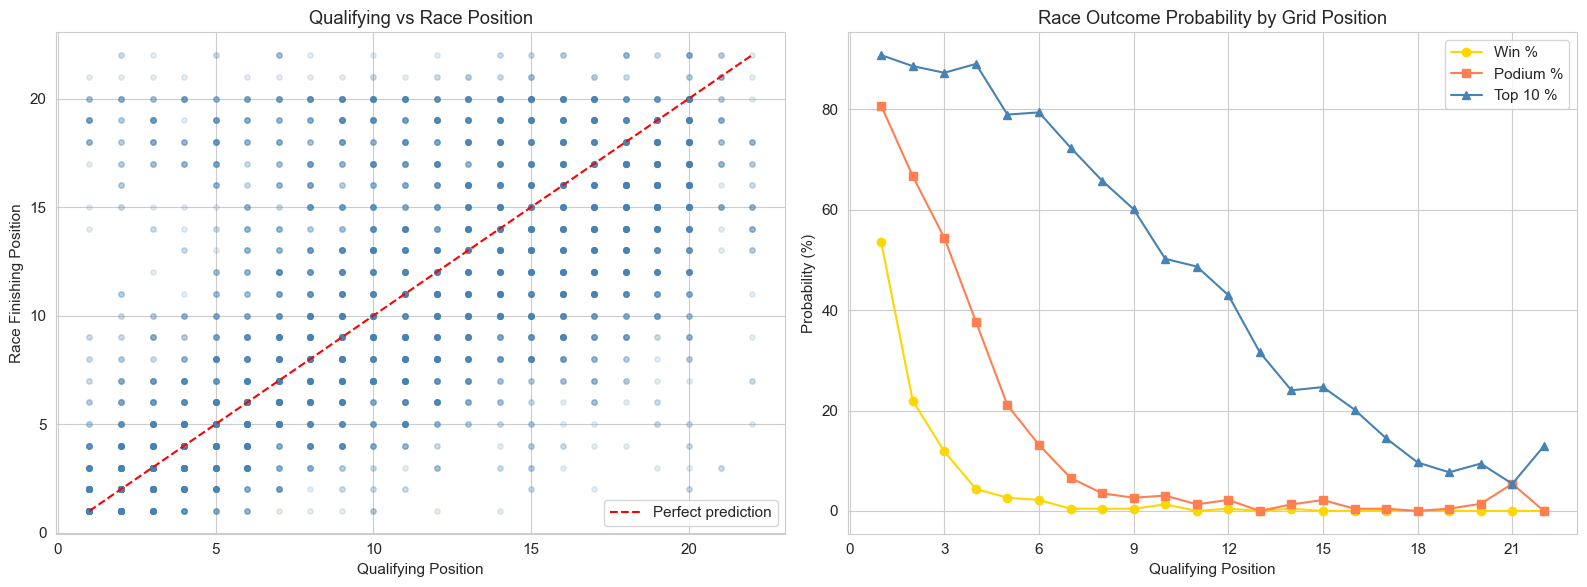


Pearson correlation (qualifying pos vs race pos): 0.632
Pole position win rate: 53.5%
Front row (P1-P2) podium rate: 73.7%


In [6]:
# --- Merge qualifying and race data ---
merged = race_df.merge(
    qual_df[['season', 'round', 'driverId', 'qualifyingPosition']],
    on=['season', 'round', 'driverId'],
    how='inner'
)
print(f"Merged dataset: {len(merged):,} rows (inner join)")

# --- Scatter: qualifying position vs finishing position ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(merged['qualifyingPosition'], merged['position'], alpha=0.15, s=15, color='steelblue')
axes[0].plot([1, 22], [1, 22], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Qualifying Position')
axes[0].set_ylabel('Race Finishing Position')
axes[0].set_title('Qualifying vs Race Position')
axes[0].legend()

# Correlation by grid position: what % of time does each grid slot win / podium / top 10?
grid_outcomes = merged.groupby('qualifyingPosition').agg(
    win_rate=('position', lambda x: (x == 1).mean()),
    podium_rate=('position', lambda x: (x <= 3).mean()),
    top10_rate=('position', lambda x: (x <= 10).mean()),
    avg_finish=('position', 'mean'),
).reset_index()

axes[1].plot(grid_outcomes['qualifyingPosition'], grid_outcomes['win_rate'] * 100, 'o-', label='Win %', color='gold')
axes[1].plot(grid_outcomes['qualifyingPosition'], grid_outcomes['podium_rate'] * 100, 's-', label='Podium %', color='coral')
axes[1].plot(grid_outcomes['qualifyingPosition'], grid_outcomes['top10_rate'] * 100, '^-', label='Top 10 %', color='steelblue')
axes[1].set_xlabel('Qualifying Position')
axes[1].set_ylabel('Probability (%)')
axes[1].set_title('Race Outcome Probability by Grid Position')
axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}qualifying_vs_race.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation coefficient
corr = merged['qualifyingPosition'].corr(merged['position'])
print(f"\nPearson correlation (qualifying pos vs race pos): {corr:.3f}")
print(f"Pole position win rate: {grid_outcomes.iloc[0]['win_rate']:.1%}")
print(f"Front row (P1-P2) podium rate: {grid_outcomes.iloc[:2]['podium_rate'].mean():.1%}")

## 2.6 Circuit Analysis

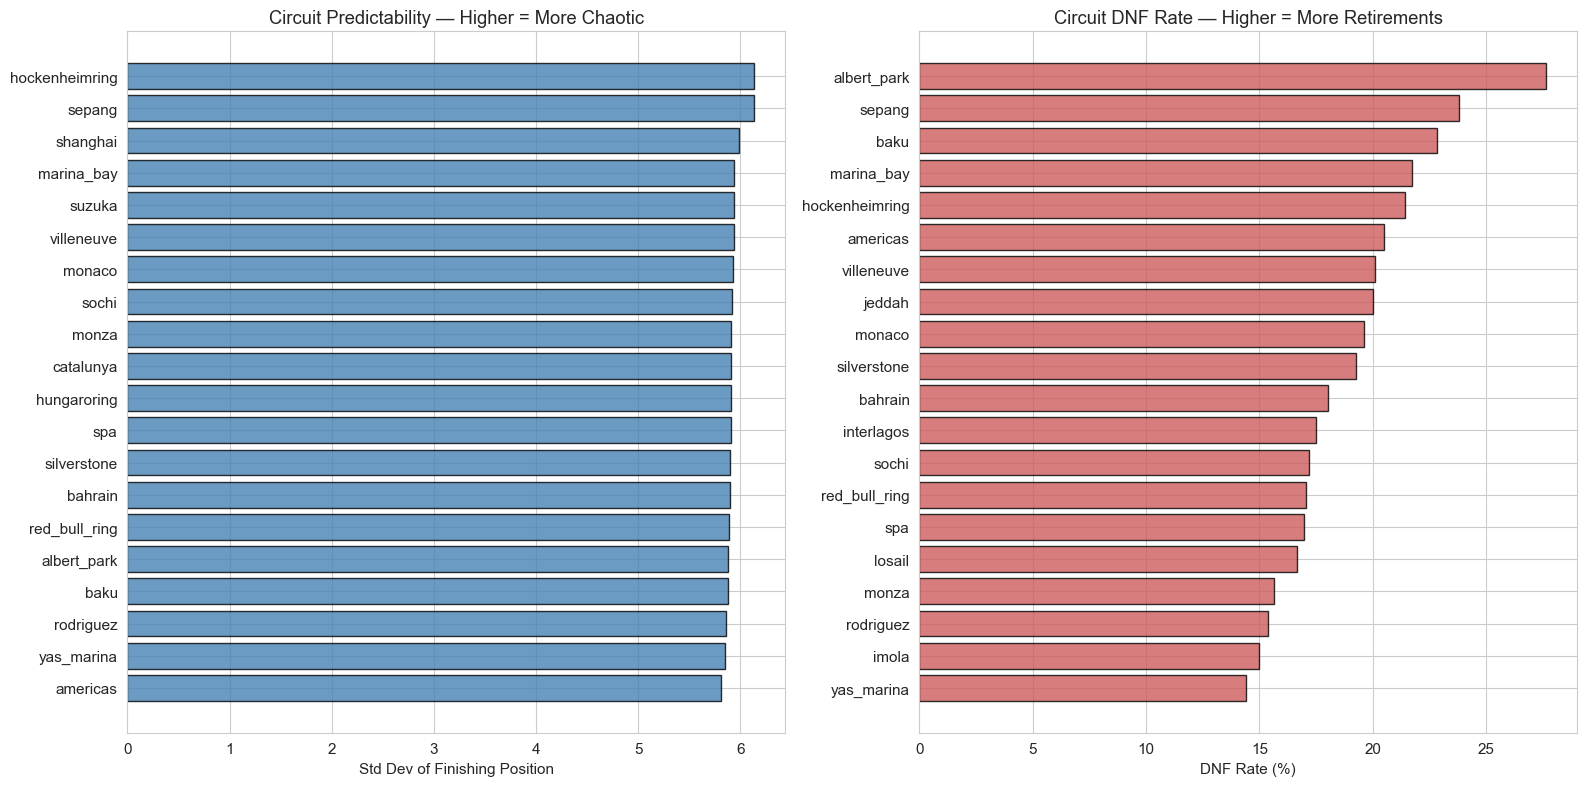

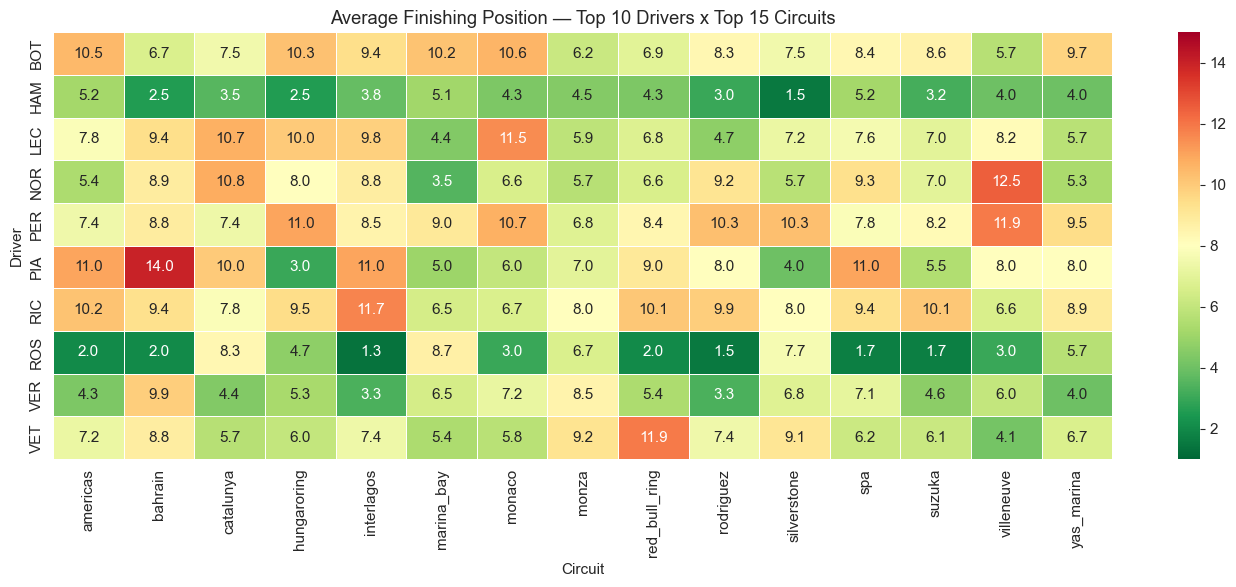

In [7]:
# --- Position variance by circuit (how much shuffling happens?) ---
circuit_stats = race_df.groupby('circuitId').agg(
    position_std=('position', 'std'),
    avg_position_gain=('position_gain', 'mean'),
    dnf_rate=('is_dnf', 'mean'),
    races_held=('season', 'nunique'),
).reset_index()

# Only circuits with 3+ seasons
circuit_stats = circuit_stats[circuit_stats['races_held'] >= 3].sort_values('position_std', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Position variance (predictability)
axes[0].barh(circuit_stats['circuitId'].head(20), circuit_stats['position_std'].head(20),
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Std Dev of Finishing Position')
axes[0].set_title('Circuit Predictability — Higher = More Chaotic')
axes[0].invert_yaxis()

# DNF rate by circuit
circuit_dnf = circuit_stats.sort_values('dnf_rate', ascending=False)
axes[1].barh(circuit_dnf['circuitId'].head(20), circuit_dnf['dnf_rate'].head(20) * 100,
             color='indianred', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('DNF Rate (%)')
axes[1].set_title('Circuit DNF Rate — Higher = More Retirements')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}circuit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Heatmap: average finish by top driver x circuit ---
top_10_drivers = driver_stats.sort_values('avg_position').head(10)['driverId'].tolist()
top_circuits = race_df['circuitId'].value_counts().head(15).index.tolist()

heatmap_data = race_df[
    (race_df['driverId'].isin(top_10_drivers)) & (race_df['circuitId'].isin(top_circuits))
].groupby(['driverCode', 'circuitId'])['position'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, vmin=1, vmax=15)
ax.set_title('Average Finishing Position — Top 10 Drivers x Top 15 Circuits')
ax.set_ylabel('Driver')
ax.set_xlabel('Circuit')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}driver_circuit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Key Findings & Implications for Feature Engineering

**Race Results:**
- Finishing positions are relatively uniform (all 20 slots get filled each race), but points are heavily right-skewed — only the top 10 score
- DNF rates vary significantly by season and circuit — this is a useful feature

**Driver Performance:**
- Clear driver skill tiers exist: Hamilton, Verstappen, and Vettel dominate the era
- Performance is NOT static — drivers improve/decline across seasons (team changes matter)
- Rolling averages over recent races will capture "form" better than career averages

**Constructor Dominance:**
- The era shows clear dominance periods (Mercedes 2014–2020, Red Bull 2021–2024)
- Team strength is the single biggest predictor — a top-3 team finishes top-6 almost always
- Team development trajectory (improving vs declining) is a useful signal

**Qualifying → Race Correlation:**
- Strong positive correlation between qualifying and race position
- Pole position converts to a win ~40% of the time — qualifying is the strongest single predictor
- However, significant scatter exists (incidents, strategy, pit stops) — room for other features

**Circuit Effects:**
- Circuits vary in "chaos" (position variance) — some are very predictable, others shuffle the grid
- DNF rates differ by circuit — street circuits and high-speed tracks show different risk profiles
- Driver-circuit affinity exists — some drivers consistently over/underperform at specific tracks

**Feature Engineering Priorities:**
1. Qualifying position (strongest single predictor)
2. Constructor/team strength metric (recent points, rolling average)
3. Driver rolling form (last 3-5 races average position)
4. Circuit characteristics (position variance, DNF rate, circuit type)
5. Driver-circuit historical performance
6. Grid position gain tendency (some drivers are better overtakers)